In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [42]:
df=pd.read_csv('badminton_data.csv')
df.head()

,right_hand_up,right_hand_above_head,right_arm_stretched,right_cross_body,right_elbow_up,lean_left,lean_right,shoulder_slope,hip_slope,right_wrist_outside,right_hand_below_hip,Pose
0,0,0,1,1,0,1,1,173.528191,-176.335921,0,0,Stance
1,0,0,1,1,0,1,1,174.128504,-176.417707,0,0,Stance
2,0,0,1,1,0,1,1,175.706907,-179.180879,0,0,Stance
3,0,0,1,1,0,1,1,177.315008,-175.959026,0,0,Stance
4,0,0,1,1,0,1,1,173.724999,-175.186167,0,0,Stance


In [43]:
df.drop(['lean_left','shoulder_slope', 'hip_slope','right_hand_below_hip','right_hand_above_head','right_arm_stretched','right_elbow_up', 'right_wrist_outside'],axis=1,inplace=True)
df

,right_hand_up,right_cross_body,lean_right,Pose
0,0,1,1,Stance
1,0,1,1,Stance
2,0,1,1,Stance
3,0,1,1,Stance
4,0,1,1,Stance
...,...,...,...,...
169,1,1,1,Smash
170,1,1,1,Smash
171,1,1,1,Smash
172,1,1,1,Smash


In [44]:
df.tail()

,right_hand_up,right_cross_body,lean_right,Pose
169,1,1,1,Smash
170,1,1,1,Smash
171,1,1,1,Smash
172,1,1,1,Smash
173,1,1,1,Smash


In [45]:
df.shape

(174, 4)

In [46]:
df.columns

Index(['right_hand_up', 'right_cross_body', 'lean_right', 'Pose'], dtype='object')

In [47]:
df.isna().sum()

right_hand_up       0
right_cross_body    0
lean_right          0
Pose                0
dtype: int64

In [48]:
df.dropna(inplace=True)

<BarContainer object of 4 artists>

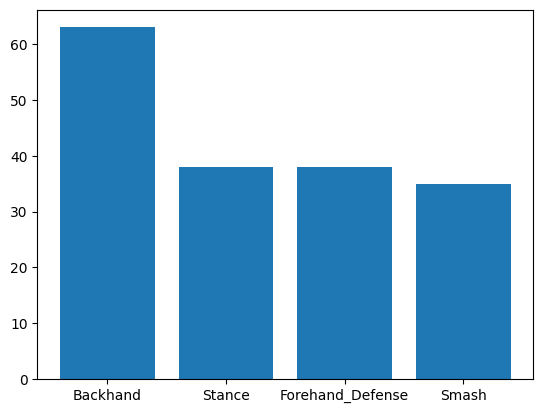

In [49]:
df1=df['Pose'].value_counts()
plt.bar(df1.index,df1.values)

In [50]:
from sklearn.preprocessing import LabelEncoder
labe=LabelEncoder()
df['Pose']=labe.fit_transform(df['Pose'])

In [51]:
x=df.iloc[:,:-1].values
x

array([[0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 1, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0,

In [52]:
y=df.iloc[:,-1].values
y

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [54]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7)
from sklearn.naive_bayes import GaussianNB
nav=GaussianNB()
from sklearn.svm import SVC
sv=SVC()
from sklearn.ensemble import RandomForestClassifier
rf_c=RandomForestClassifier(criterion='entropy')
from sklearn.tree import DecisionTreeClassifier
d_tree_c=DecisionTreeClassifier(criterion='entropy')
from xgboost import XGBClassifier
xgb_c=XGBClassifier()
models=[knn,nav,sv,rf_c,d_tree_c,xgb_c]
for model in models:
    print(model)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))

KNeighborsClassifier(n_neighbors=7)
[[18  0  0  0]
 [ 0 13  0  0]
 [ 0  0 10  0]
 [ 0  0  0 12]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        12

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weighted avg       1.00      1.00      1.00        53

GaussianNB()
[[18  0  0  0]
 [ 0 13  0  0]
 [ 0  0 10  0]
 [ 0  0  0 12]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        12

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weight

In [55]:
joblib.dump(d_tree_c,'banminton_pose_model.pkl')

['banminton_pose_model.pkl']

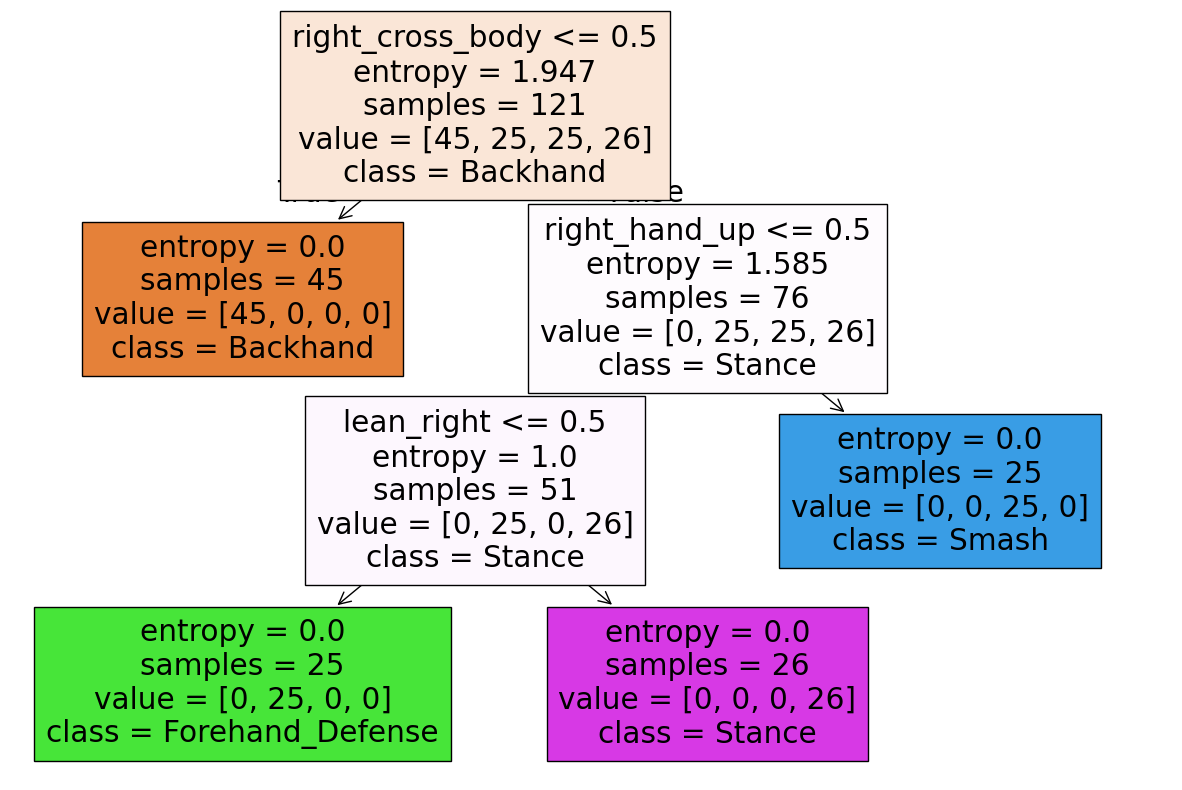

In [56]:
from sklearn import tree
import matplotlib.pyplot as plt

# Draw tree
plt.figure(figsize=(15,10))

tree.plot_tree(
    d_tree_c,
    feature_names=df.columns,   # your feature names
    class_names=['Backhand', 'Forehand_Defense', 'Smash', 'Stance'],
    filled=True
)

plt.show()